# 연극 + 뮤지컬 합산
* 여긴 협업 필터링을 위해 별점만 합쳐놨음

In [ ]:
# 연극_평점
import pandas as pd
play_star = pd.read_excel("../data/raw/playTop77_star.xlsx")
play_star

,Unnamed: 0,Title,ID,Star,Date
0,5316,연극 〈운빨로맨스〉- 대학로,seeun0***,5,2023.10.10
1,5317,연극 〈운빨로맨스〉- 대학로,isoo9***,5,2023.10.10
2,5318,연극 〈운빨로맨스〉- 대학로,rkgml5***,5,2023.10.09
3,5324,연극 〈운빨로맨스〉- 대학로,da9***,5,2023.10.03
4,5325,연극 〈운빨로맨스〉- 대학로,4322***,5,2023.09.28
...,...,...,...,...,...
9725,9818,그곳에 있었다,judy7***,5,2023.09.14
9726,9819,그곳에 있었다,ddhj***,5,2023.09.03
9727,9820,그곳에 있었다,gustnr4***,5,2023.09.03
9728,9821,그곳에 있었다,pinkhwan***,5,2023.09.03


In [ ]:
musical_star = pd.read_excel("../data/raw/musicalTop77_star.xlsx")
musical_star

,Unnamed: 0,Title,ID,Star,Date
0,11891,난타(NANTA) - 명동공연,zzong2***,5,2023.10.10
1,11892,난타(NANTA) - 명동공연,zzong2***,5,2023.10.10
2,11893,난타(NANTA) - 명동공연,bi***,5,2023.10.10
3,11894,난타(NANTA) - 명동공연,kbw9***,5,2023.10.06
4,11895,난타(NANTA) - 명동공연,eng***,5,2023.10.06
...,...,...,...,...,...
12560,13103,뮤지컬 스크루테이프의 편지,hatnimyi***,5,2022.06.26
12561,13104,뮤지컬 스크루테이프의 편지,gein***,5,2022.06.04
12562,13105,뮤지컬 스크루테이프의 편지,jy961***,5,2022.02.03
12563,13106,뮤지컬 스크루테이프의 편지,ctg0***,5,2022.01.12


In [ ]:
# 연극 + 뮤지컬 합산
total_star = pd.concat([play_star, musical_star])
total_star = total_star.drop(['Unnamed: 0'], axis=1)
total_star = total_star.reset_index(drop=True)
total_star.to_excel('../data/raw/total_star.xlsx')
total_star

,Title,ID,Star,Date
0,연극 〈운빨로맨스〉- 대학로,seeun0***,5,2023.10.10
1,연극 〈운빨로맨스〉- 대학로,isoo9***,5,2023.10.10
2,연극 〈운빨로맨스〉- 대학로,rkgml5***,5,2023.10.09
3,연극 〈운빨로맨스〉- 대학로,da9***,5,2023.10.03
4,연극 〈운빨로맨스〉- 대학로,4322***,5,2023.09.28
...,...,...,...,...
22290,뮤지컬 스크루테이프의 편지,hatnimyi***,5,2022.06.26
22291,뮤지컬 스크루테이프의 편지,gein***,5,2022.06.04
22292,뮤지컬 스크루테이프의 편지,jy961***,5,2022.02.03
22293,뮤지컬 스크루테이프의 편지,ctg0***,5,2022.01.12


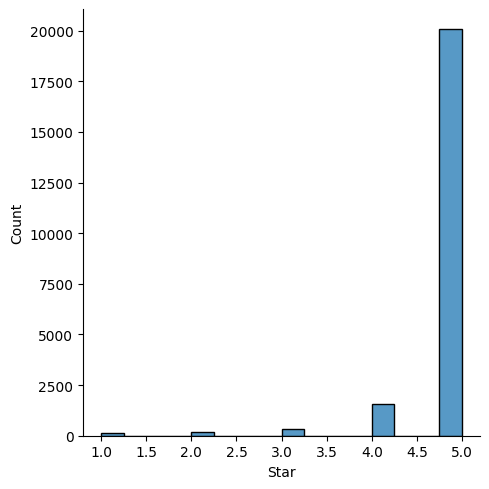

In [ ]:
import seaborn as sns
sns.displot(total_star['Star'])

In [ ]:
user_stastics = pd.DataFrame({
    'numRating' : total_star.groupby('ID')['Title'].nunique(),
    'avgRating' : total_star.groupby('ID')['Star'].mean(),
    'stdRating' : total_star.groupby('ID')['Star'].std(),
}).reset_index()

print("총 유저의 수: " , user_stastics.shape[0])
user_stastics.head()

총 유저의 수:  11809


,ID,numRating,avgRating,stdRating
0,***,29,4.872659,0.504381
1,000rb***,2,5.000000,0.000000
2,005***,2,5.000000,0.000000
3,007***,1,5.000000,NaN
4,00friend***,1,5.000000,NaN


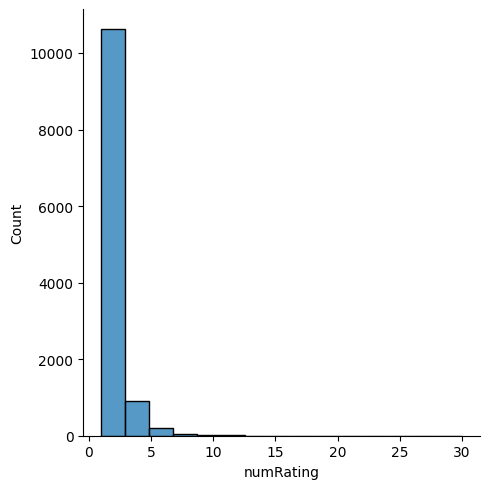

In [ ]:
# 사용자 평가 영화 개수 분포
sns.displot(user_stastics['numRating'])

In [ ]:
# 리뷰 1개 남긴 사람들
user_stastics[user_stastics['numRating'] == 1]

,ID,numRating,avgRating,stdRating
3,007***,1,5.0,NaN
4,00friend***,1,5.0,NaN
5,00s***,1,5.0,NaN
6,01020259***,1,5.0,0.0
7,01023712***,1,5.0,NaN
...,...,...,...,...
11804,zzzjsi2***,1,5.0,NaN
11805,zzzm***,1,1.0,NaN
11806,zzzzz0***,1,5.0,NaN
11807,zzzzz8***,1,5.0,NaN


In [ ]:
# 리뷰 2개 이상 쓴 사람들
user_stastics[user_stastics['numRating'] > 1]

,ID,numRating,avgRating,stdRating
0,***,29,4.872659,0.504381
1,000rb***,2,5.000000,0.000000
2,005***,2,5.000000,0.000000
17,01rk***,2,4.000000,0.000000
19,02030***,2,5.000000,0.000000
...,...,...,...,...
11792,zzangir***,3,5.000000,0.000000
11793,zzanglee1***,3,2.500000,1.914854
11796,zzo***,2,4.000000,0.000000
11799,zzyouz***,4,5.000000,0.000000


In [ ]:
# 연극 + 뮤지컬에서 2번 이상 리뷰남긴 사람들의 리뷰들
total_star[total_star.duplicated(subset='ID')]

,Title,ID,Star,Date
16,연극 〈운빨로맨스〉- 대학로,ash1***,5,2023.09.08
20,연극 〈운빨로맨스〉- 대학로,kdh10***,5,2023.09.05
44,연극 〈운빨로맨스〉- 대학로,jm***,5,2023.08.07
47,연극 〈운빨로맨스〉- 대학로,chltnwjd0***,5,2023.08.06
56,연극 〈운빨로맨스〉- 대학로,duck71p***,5,2023.08.01
...,...,...,...,...
22275,뮤지컬 〈투모로우 모닝〉,gpwnsla7***,5,2023.08.16
22276,뮤지컬 〈투모로우 모닝〉,bo5***,5,2023.08.14
22280,뮤지컬 스크루테이프의 편지,goodlove1***,5,2023.06.12
22282,뮤지컬 스크루테이프의 편지,cae***,5,2023.03.12


* 2,500명 정도의 사람들이 쓴 리뷰가 총 10,000개

In [ ]:
# 동일한 ID가 동일한 Title에 대해서 남긴 평점은 평균값으로 처리
pivot_df = total_star.pivot_table(index='ID', columns='Title', values='Star', aggfunc='mean')
# *** 아이디 삭제
pivot_df = pivot_df.drop(pivot_df.index[0])
pivot_df = pivot_df.fillna(0)
pivot_df

Title,(리얼타임 코믹연극) 택시안에서 - 서울,(코믹연극) 달동네-부산,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,2023 연극 〈친정엄마와 2박 3일〉 - 고양,2시간탈출 졸탄쇼,3대가 웃고 우는 연극 〈염쟁이 유씨〉,4D공포연극 〈스위치〉,★평점9.5★ 코미디의맛/쇼미더퍼니,공포스릴러연극〈두여자〉- 대구,공포연극 조각,...,이머시브씨어터 카지노,이은결 ［더 일루션 - 마스터피스］,좀비연극 오마이갓,진짜나쁜소녀,코미디 연극〈딜리버리〉,코믹감동 휴먼판타지 연극 〈2호선 세입자〉,행오버,［2023 SPAF］ 극단 돌파구 〈지상의 여자들〉,［서울 대학로］연극 라면,"［청주,세종］뮤지컬 빌의구둣방"
ID,,,,,,,,,,,,,,,,,,,,,
000rb***,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
005***,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
007***,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00friend***,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
00s***,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zzzjsi2***,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0
zzzm***,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
zzzzz0***,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 협업필터링

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

def get_rmse(R, P, Q, non_zeros):
    error = 0
    # 두개의 분해된 행렬 P와 Q.T의 내적 곱으로 예측 R 행렬 생성
    full_pred_matrix = np.dot(P, Q.T)

    # 실제 R 행렬에서 널이 아닌 값의 위치 인덱스 추출하여 실제 R 행렬과 예측 행렬의 RMSE 추출
    x_non_zero_ind = [non_zero[0] for non_zero in non_zeros]
    y_non_zero_ind = [non_zero[1] for non_zero in non_zeros]
    R_non_zeros = R[x_non_zero_ind, y_non_zero_ind]

    full_pred_matrix_non_zeros = full_pred_matrix[x_non_zero_ind, y_non_zero_ind]

    mse = mean_squared_error(R_non_zeros, full_pred_matrix_non_zeros)
    rmse = np.sqrt(mse)

    return rmse

In [ ]:
def matrix_factorization(R, K, steps=200, learning_rate=0.01, r_lambda = 0.01):
    num_users, num_items = R.shape
    # P와 Q 매트릭스의 크기를 지정하고 정규분포를 가진 랜덤한 값으로 입력합니다.
    np.random.seed(1)
    P = np.random.normal(scale=1./K, size=(num_users, K))
    Q = np.random.normal(scale=1./K, size=(num_items, K))

    break_count = 0

    # R > 0 인 행 위치, 열 위치, 값을 non_zeros 리스트 객체에 저장.
    non_zeros = [ (i, j, R[i,j]) for i in range(num_users) for j in range(num_items) if R[i,j] > 0 ]

    # SGD기법으로 P와 Q 매트릭스를 계속 업데이트.
    for step in range(steps):
        for i, j, r in non_zeros:
            # 실제 값과 예측 값의 차이인 오류 값 구함
            eij = r - np.dot(P[i, :], Q[j, :].T)
            # Regularization을 반영한 SGD 업데이트 공식 적용
            P[i,:] = P[i,:] + learning_rate*(eij * Q[j, :] - r_lambda*P[i,:])
            Q[j,:] = Q[j,:] + learning_rate*(eij * P[i, :] - r_lambda*Q[j,:])

        rmse = get_rmse(R, P, Q, non_zeros)
        if (step % 10) == 0 :
            print("### iteration step : ", step," rmse : ", rmse)

    return P, Q

In [ ]:
P, Q = matrix_factorization(pivot_df.values, K=50, steps=200, learning_rate=0.01, r_lambda = 0.01)
pred_matrix = np.dot(P, Q.T)

### iteration step :  0  rmse :  4.859813043156199
### iteration step :  10  rmse :  0.4747636218515914
### iteration step :  20  rmse :  0.15651240858795534
### iteration step :  30  rmse :  0.08953775817763482
### iteration step :  40  rmse :  0.06525053793574208
### iteration step :  50  rmse :  0.05817221532940333
### iteration step :  60  rmse :  0.05354357339339101
### iteration step :  70  rmse :  0.04992442462248396
### iteration step :  80  rmse :  0.04716792049858878
### iteration step :  90  rmse :  0.04500818518431909
### iteration step :  100  rmse :  0.043214745716051856
### iteration step :  110  rmse :  0.04165723965784072
### iteration step :  120  rmse :  0.0402710046137485
### iteration step :  130  rmse :  0.039021327807607115
### iteration step :  140  rmse :  0.03788610667928627
### iteration step :  150  rmse :  0.03684913435070453
### iteration step :  160  rmse :  0.03589756463243925
### iteration step :  170  rmse :  0.035020835200331175
### iteration step :  

In [ ]:
ratings_pred_matrix = pd.DataFrame(data=pred_matrix, index= pivot_df.index,
                                   columns = pivot_df.columns)

ratings_pred_matrix.head(3)

Title,(리얼타임 코믹연극) 택시안에서 - 서울,(코믹연극) 달동네-부산,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,2023 연극 〈친정엄마와 2박 3일〉 - 고양,2시간탈출 졸탄쇼,3대가 웃고 우는 연극 〈염쟁이 유씨〉,4D공포연극 〈스위치〉,★평점9.5★ 코미디의맛/쇼미더퍼니,공포스릴러연극〈두여자〉- 대구,공포연극 조각,...,이머시브씨어터 카지노,이은결 ［더 일루션 - 마스터피스］,좀비연극 오마이갓,진짜나쁜소녀,코미디 연극〈딜리버리〉,코믹감동 휴먼판타지 연극 〈2호선 세입자〉,행오버,［2023 SPAF］ 극단 돌파구 〈지상의 여자들〉,［서울 대학로］연극 라면,"［청주,세종］뮤지컬 빌의구둣방"
ID,,,,,,,,,,,,,,,,,,,,,
000rb***,1.491872,0.667738,1.158053,0.329178,2.232208,2.325084,0.826418,0.016730,0.314584,1.168666,...,4.374956,2.541752,1.069606,2.486157,2.444114,2.350014,2.632695,4.314828,2.043708,-0.983949
005***,2.732398,0.499613,1.639042,0.801060,1.946146,2.198724,0.594553,1.139491,1.144847,2.383964,...,1.733164,2.029740,2.031904,3.791840,3.459792,2.821775,3.480251,1.027553,2.332742,-0.118017
007***,2.618429,0.179641,0.425387,1.201983,4.961823,1.513690,-0.552769,0.432839,0.216423,1.163385,...,1.630150,1.592602,0.231791,2.238582,1.438650,1.227397,1.304631,1.525374,0.771816,-0.499174


In [ ]:
def get_unseen_movies(ratings_matrix, userId):
    # userId로 입력받은 사용자의 모든 영화정보 추출하여 Series로 반환함.
    # 반환된 user_rating 은 영화명(title)을 index로 가지는 Series 객체임.
    user_rating = ratings_matrix.loc[userId,:]

    # user_rating이 0보다 크면 기존에 관람한 영화임. 대상 index를 추출하여 list 객체로 만듬
    already_seen = user_rating[ user_rating > 0].index.tolist()

    # 모든 영화명을 list 객체로 만듬.
    movies_list = ratings_matrix.columns.tolist()

    # list comprehension으로 already_seen에 해당하는 movie는 movies_list에서 제외함.
    unseen_list = [ movie for movie in movies_list if movie not in already_seen]

    return unseen_list

In [ ]:
def recomm_movie_by_userid(pred_df, userId, unseen_list, top_n=10):
    # 예측 평점 DataFrame에서 사용자id index와 unseen_list로 들어온 영화명 컬럼을 추출하여
    # 가장 예측 평점이 높은 순으로 정렬함.
    recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]
    return recomm_movies

In [ ]:
userid = 'aeson***'
# 사용자가 관람하지 않은 영화명 추출
unseen_list = get_unseen_movies(pivot_df, userid)

# 아이템 기반의 인접 이웃 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, userid, unseen_list, top_n=10)

# 평점 데이타를 DataFrame으로 생성.
recomm_movies = pd.DataFrame(data=recomm_movies.values,index=recomm_movies.index,columns=['pred_score'])
recomm_movies

,pred_score
Title,
연극 〈나의PS파트너〉,5.063212
행오버,4.851049
뮤지컬 〈삼총사〉,4.806959
뮤직드라마 당신만이,4.702204
뮤지컬 〈김종욱 찾기〉,4.665797
뮤지컬 ＇벤허＇,4.651193
뮤지컬 〈멤피스〉,4.584167
연극 〈극적인 하룻밤〉,4.562937
로맨틱코미디 〈슬기로운 신혼생활〉,4.561914


# 컨텐츠 기반(가중치종합:코드가 매우 긺. 펼치지 말고 돌릴 것)
* 일단은 최종 결과 형식이 동일하니, 테스트를 위해 장르/줄거리 분리 코드 활용
* 이쪽도 연극 + 뮤지컬 합쳐뒀음

In [ ]:
play_top = "../data/raw/theater_top77.xlsx"
musical_top = "../data/raw/musical_top77.xlsx"
play_top_star = "../data/raw/playTop77_star.xlsx"
musical_top_star = "../data/raw/musicalTop77_star.xlsx"
play_actor_lank = "../data/raw/theater_actor_rank.csv"
musical_actor_lank = "../data/raw/musical_actor_rank.csv"
play_top_cast = "../data/raw/playTop77_casting.xlsx"
musical_top_cast = "../data/raw/musicalTop77_casting.xlsx"

In [ ]:
def concat_play_musical(play, musical):
  try:
    playdf = pd.read_excel(play)
    musicaldf = pd.read_excel(musical)
  except:
    playdf = pd.read_csv(play)
    musicaldf = pd.read_csv(musical)
  df = pd.concat([playdf, musicaldf])
  df = df.drop(['Unnamed: 0'], axis=1)
  df = df.reset_index(drop=True)
  return df

In [ ]:
top_lank = concat_play_musical(play_top, musical_top)
top_star = concat_play_musical(play_top_star, musical_top_star)
actor_lank = concat_play_musical(play_actor_lank, musical_actor_lank)
top_cast = concat_play_musical(play_top_cast, musical_top_cast)

In [ ]:
actor_lank.index

RangeIndex(start=0, stop=200, step=1)

## 줄거리 유사도

In [ ]:
# 형태소 분석기 Mecab 설치
!pip install konlpy
!pip install mecab-python #표준어에 비표준어 모두 추가한것
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 51.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.3/465.3 kB 45.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.7/581.7 kB 5.5 MB/s eta 0:00:00
  Created wheel for mecab-python: filename=mecab_python-1.0.0-py3-none-any.whl size=1231 sha256=5481ebea3e8bb4260a50f6a23cd4bf0059d4bc1ac56a620a4aafe7f926852e7b
  Stored in directory: /root/.cache/pip/wheels/ec/41/c8/ce8fb469be2547ce596c4000613806505dc54c296aae45da71
Successfully built mecab-python
Install mecab-ko
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1381k  100 1381k    0     0  1174k      0  0:00:01  0:00:01 --:--:-- 1174k
mecab-0.996-ko-0.9.2/
mecab-0.996-ko-0.9.2/example/
mecab-0.996-ko-0.9.2/example

In [ ]:
import pandas as pd
from konlpy.tag import Mecab
from gensim.models.doc2vec import TaggedDocument
from tqdm import tqdm

In [ ]:
def plot_similarlity(top70_df):
  df=top70_df[['Title', '공연소개', '줄거리', '장르']]
  df
  mecab = Mecab()

  tagged_corpus_list = []

  for index, row in tqdm(df.iterrows(), total=len(df)):
    text = str(row['줄거리'])  # 문자열로 변환
    tag = str(row['Title'])    # 문자열로 변환
    tagged_corpus_list.append(TaggedDocument(tags=[tag], words=mecab.morphs(text)))

  print('문서의 수 :', len(tagged_corpus_list))
  from gensim.models import doc2vec

  model = doc2vec.Doc2Vec(vector_size=300, alpha=0.025, min_alpha=0.025, workers=8, window=8)

  # Vocabulary 빌드
  model.build_vocab(tagged_corpus_list)
  # print(f"Tag Size: {len(model.docvecs.doctags.keys())}", end=' / ')

  # Doc2Vec 학습
  model.train(tagged_corpus_list, total_examples=model.corpus_count, epochs=100)  # 원래 epochs 값 50

  # 모델 저장
  model.save('dart.doc2vec')
  return model

In [ ]:
plot_model = plot_similarlity(top_lank)

100%|██████████| 142/142 [00:00<00:00, 1024.20it/s]


문서의 수 : 142


In [ ]:
similar_doc = plot_model.docvecs.most_similar('［서울 대학로］연극 라면', topn=70)
print(similar_doc)

[('［2023_셀러브리티 명품 로코］ 연극 이프온리 크리스마스특별 공연 _ 전주', 0.5075640678405762), ('［2023_셀러브리티 명품 로코］연극 이프온리 크리스마스특별 공연 - 인천', 0.5074360370635986), ('［2023’셀러브리티 로코연극］러브액츄얼리 첫번째사연_크리스마스 특별공연 - 부산', 0.4980386197566986), ('［2023_셀러브리티 명품 로코］연극 이프온리 크리스마스특별 공연 - 광주', 0.49618643522262573), ('［2023_셀러브리티 명품 로코］ 연극 이프온리 크리스마스특별 공연 - 울산', 0.4953157305717468), ('［2023_셀러브리티 명품 로코］연극 이프온리 크리스마스특별 공연 - 대구', 0.49044522643089294), ('［2023_셀러브리티 명품 로코］연극 이프온리 크리스마스특별 공연 - 대전', 0.4844554662704468), ('연극 핫식스', 0.47601157426834106), ('［2023_셀러브리티 명품 로코］연극 이프온리 크리스마스특별 공연 - 고양', 0.47506409883499146), ('［2023_셀러브리티 명품 로코］연극 이프온리 크리스마스특별 공연 - 대학로', 0.4734483063220978), ('(리얼타임 코믹연극) 택시안에서 - 서울', 0.4259547293186188), ('나의 장례식에 와줘', 0.4101354479789734), ('뮤지컬 〈스토리오브마이라이프〉', 0.39654040336608887), ('(리얼타임 코믹연극) 택시안에서 - 부산', 0.39293041825294495), ('뮤지컬 〈스모크〉', 0.38944464921951294), ('어른이 뮤지컬 〈난쟁이들〉', 0.3821714520454407), ('라면에 파송송', 0.3746480643749237), ('모든 날 모든 순간', 0.3730319142341614), ('뮤지컬 〈투모로우 모닝〉', 0.371243327856

<ipython-input-28-7f441c99b1de>:1: DeprecationWarning: Call to deprecated `docvecs` (The `docvecs` property has been renamed `dv`.).
  similar_doc = plot_model.docvecs.most_similar('［서울 대학로］연극 라면', topn=70)


In [ ]:
similar_doc = plot_model.docvecs.most_similar('태양의서커스 〈루치아〉')
print(similar_doc)

[('2023 매직쇼〈최현우의 미스틱커스〉 - 평택', 0.5683559775352478), ('［2023_셀러브리티 명품 로코］연극 이프온리 크리스마스특별 공연 - 인천', 0.5504379272460938), ('［2023’셀러브리티 로코연극］러브액츄얼리 첫번째사연_크리스마스 특별공연 - 부산', 0.523152232170105), ('［2023_셀러브리티 명품 로코］연극 이프온리 크리스마스특별 공연 - 대구', 0.5171200633049011), ('［2023_셀러브리티 명품 로코］연극 이프온리 크리스마스특별 공연 - 광주', 0.5140581727027893), ('뮤지컬 〈투모로우 모닝〉', 0.5083099007606506), ('뮤지컬 더데빌 : 에덴 (Musical THE DEVIL : EDEN)', 0.5052580237388611), ('［2023_셀러브리티 명품 로코］연극 이프온리 크리스마스특별 공연 - 고양', 0.5020853281021118), ('［2023_셀러브리티 명품 로코］ 연극 이프온리 크리스마스특별 공연 - 울산', 0.5007256865501404), ('［2023_셀러브리티 명품 로코］ 연극 이프온리 크리스마스특별 공연 _ 전주', 0.5007041692733765)]


<ipython-input-29-f6289f445eb8>:1: DeprecationWarning: Call to deprecated `docvecs` (The `docvecs` property has been renamed `dv`.).
  similar_doc = plot_model.docvecs.most_similar('태양의서커스 〈루치아〉')


## 장르 유사도

In [ ]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import random
from matplotlib import pyplot as plt
from datetime import datetime
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

In [ ]:
def genre_similarlity(top70_df, title_name):
  df=top70_df[['Title', '장르']]
  from sklearn.feature_extraction.text import TfidfVectorizer

  #df 장르에 존재하는 공백 형식이 갖추어지지 않아있어서 공백있는거 공백 제거하기
  df['장르']=df['장르'].str.replace(' ', '').str.replace(',', ', ')

  #그 다음 ,를 기준으로 장르 나눠주기
  df['genres_literal']=df['장르'].str.split(',')
  df['genres_literal'] = df['genres_literal'].apply(lambda x : (' ').join(x))
  #df
  tfidf_vect = TfidfVectorizer()
  genre_mat1=tfidf_vect.fit_transform(df['genres_literal'])

  from sklearn.metrics.pairwise import cosine_similarity

  genre_sim1 = cosine_similarity(genre_mat1, genre_mat1)#똑같은 메트릭스를 두개 집어넣는다.

  genre_sim_sorted_ind1 = genre_sim1.argsort()[:, ::-1] #내림차순으로 sorting해서 보여줘.

  # 인자로 입력된 movies_df DataFrame에서 'title' 컬럼이 입력된 title_name 값인 DataFrame 추출
  title_movie = df[df['Title'] == title_name]

  # title_name을 가진 DataFrame의 index 객체를 ndarray로 반환하고
  # sorted_ind 인자로 입력된 genre_sim_sorted_ind 객체에서 유사도 순으로 top_n 개의 index 추출
  title_index = title_movie.index.values
  similar_indexes = genre_sim_sorted_ind1[title_index, :]  # Include one extra for the input movie

  # 추출된 top_n+1 index들 출력. top_n+1 index는 2차원 데이터임.
  # dataframe에서 index로 사용하기 위해서 1차원 array로 변경
  similar_indexes = similar_indexes.reshape(-1)

  # 유사한 영화 중에 유사도가 높은 순으로 정렬한 인덱스에 대응되는 유사도 추출
  similar_scores = genre_sim1[title_index, similar_indexes]

  # DataFrame으로 만들고 유사도가 높은 순으로 정렬
  similar_movie_df = df.iloc[similar_indexes]
  similar_movie_df['Cosine_Similarity'] = similar_scores  # Add cosine similarity scores to the DataFrame

  # Round the cosine similarity values to two decimal places
  similar_movie_df['Cosine_Similarity'] = similar_movie_df['Cosine_Similarity'].round(2)

  similar_movie_df = similar_movie_df[['Title', 'Cosine_Similarity']]

  # Exclude the input movie from the result
  similar_movie_df = similar_movie_df[similar_movie_df['Title'] != title_name]

  return similar_movie_df

def genre_sim(title):
  similar_df = genre_similarlity(top_lank, title)
  return similar_df

In [ ]:
genre_sim('4D공포연극 〈스위치〉')

,Title,Cosine_Similarity
72,공포스릴러연극〈두여자〉- 대구,0.92
12,공포연극 조각,0.87
13,공포연극 ［자취］,0.87
38,좀비연극 오마이갓,0.53
36,이머시브씨어터 카지노,0.42
...,...,...
100,뮤지컬 〈렛미플라이〉,0.00
101,뮤지컬 〈마리 퀴리〉,0.00
102,뮤지컬 〈맘마미아!〉 - 김해,0.00
103,뮤지컬 〈렌트〉,0.00


## 별점 가중치 함수


*   변수가 적절히 잘 쓰였는지 확인(코드 이해)
*   변경할 점 있으면 변수 바꾼다.



연극 별점가중치


코드 설명
1.   1+review_count: 리뷰 수에 1을 더함. 분모가 0이되는 것을 방지하기 위해.
2.   항목 추가



In [ ]:
# user_ratings : 별점리스트, review_count: 전체 행개수
def calculate_weighted_rating (user_ratings, review_count, base_weight=1.0):

  # 가중치 계산
  weight = base_weight*( 1.0 + review_count)    # 사람 수가 적을수록 가중치 감소/ 기본 가중치값 먼저 필요

  # 평균 별점 계산
  average_rating = sum(user_ratings)/len(user_ratings)   # 작품명 같은 것끼리 계산

  # 가중 평균 별점 계산
  weighted_rating = average_rating*weight

  return weighted_rating

In [ ]:
def star_weight(star_df):
  import pandas as pd
  star = star_df['Star']
  num_play = star_df.shape[0]

  # 일단 작품이름 같은 것끼리 묶어야함
  # 묶은 것에서 user_rating 리스트 만들기
  # 묶은 것 아이템 개수=작품별 리뷰 개수 계산
  # for문 이용해서 작품 하나씩 들어가서 돌려야함.
  # 결과  --> 작품: 가중치 이런식으로 아웃풋.

  # 제목별로 별점 그룹화
  grouped_title = star_df.groupby('Title')['Star'].apply(list).reset_index()
  type(grouped_title)

  # 별점 가중치 함수 데이터에 적용

  review_count = 100
  weighted_ratings = {}

  for row in grouped_title.itertuples():
    title = row.Title
    user_ratings = row.Star

    # 가중 평균 계산 함수 호출
    weighted_rating = calculate_weighted_rating(user_ratings, review_count=len(user_ratings))
    weighted_ratings[title] = weighted_rating


  for title, weighted_rating in weighted_ratings.items():
      print(f"Title: {title}, Weighted Rating: {weighted_rating}")
  return weighted_ratings

In [ ]:
weighted_ratings = star_weight(top_star)

Title: (리얼타임 코믹연극) 택시안에서 - 서울, Weighted Rating: 1005.744075829384
Title: (코믹연극) 달동네-부산, Weighted Rating: 73.92857142857143
Title: 10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀, Weighted Rating: 2462.819607843137
Title: 2023 연극 〈친정엄마와 2박 3일〉 - 고양, Weighted Rating: 33.142857142857146
Title: 2시간탈출 졸탄쇼, Weighted Rating: 653.7720588235295
Title: 3대가 웃고 우는 연극 〈염쟁이 유씨〉, Weighted Rating: 68.92307692307693
Title: 4D공포연극 〈스위치〉, Weighted Rating: 2457.9555555555557
Title: ★평점9.5★ 코미디의맛/쇼미더퍼니, Weighted Rating: 2124.7640449438204
Title: 공포스릴러연극〈두여자〉- 대구, Weighted Rating: 310.0
Title: 공포연극 조각, Weighted Rating: 617.7890625
Title: 공포연극 ［자취］, Weighted Rating: 966.81
Title: 국민 코믹 연극 〈오백에삼십〉 - 대학로 세우아트센터 1관, Weighted Rating: 2800.8966725043783
Title: 그곳에 있었다, Weighted Rating: 57.81818181818182
Title: 나의 장례식에 와줘, Weighted Rating: 73.92857142857143
Title: 난타(NANTA) - 명동공연, Weighted Rating: 790.8518518518518
Title: 대학로 1위 연극 〈쉬어매드니스〉, Weighted Rating: 2432.7607843137253
Title: 대학로 청소년연극 〈사춘기메들리〉, Weighted Rating: 716.9444444444

## 배우 가중치 함수

### PlayDB 누적조회순 랭킹 불러오기

---

 - actor_dic 딕셔너리 구조

{ 배우 : { 'index': 순위, 'masterpiece' : [최근공연 3개 리스트] } }




In [ ]:
import pandas as pd
def actor_lanking(actor_csv):
  actor_csv = actor_csv.reset_index()
  actor_csv.columns = ["index", "actor_name", "masterpiece"]

  # 랭킹에 있는 배우들의 작품만 따로 추출 (작품명이 \n으로 이어진 하나의 문자열이기 때문에, 리스트화 시킬 예정)
  actor_mp = actor_csv['masterpiece'].to_list()

  actor_dic = actor_csv.set_index('index').T.to_dict()  # 딕셔너리 형태로 변환

  # key: actor_name, value: index, masterpiece
  for key, value in actor_dic.items():
    temp = value['masterpiece']
    temp2 = temp.split('\n')
    value['masterpiece'] = temp2
  return actor_dic

In [ ]:
actor_dic = actor_lanking(actor_lank)
actor_dic

{0: {'actor_name': '최성희', 'masterpiece': ['몽실(2009)']},
 1: {'actor_name': '김다현',
  'masterpiece': ['루쓰(2023)',
   '더 그레이티스트 뮤지컬 콘서트 - 용인(2022)',
   '미세스 다웃파이어(2022)']},
 2: {'actor_name': '김지현',
  'masterpiece': ['그날들 - 대구(2023)', '그날들(2023)', '스위니토드(2022)']},
 3: {'actor_name': '박호산',
  'masterpiece': ['기형도 플레이(2023)', '오셀로(2023)', '무제의 시대(2022)']},
 4: {'actor_name': '윤주상',
  'masterpiece': ['타클라마칸(2018)',
   '웃어요 덕구씨(2016)',
   '2012 세계국립극장페스티벌 - 인물실록 봉달수(2012)']},
 5: {'actor_name': '조재현',
  'masterpiece': ['블랙버드(2016)',
   '2016 여우락페스티벌 - 2 조재현 황석정 두번째달(2016)',
   '에쿠우스(2015)']},
 6: {'actor_name': '이현수',
  'masterpiece': ['제11회 대구국제뮤지컬페스티벌 - 아름다운 슬픈 날(2017)',
   '화려한 싱글들(2012)',
   '순이야 사랑해(2012)']},
 7: {'actor_name': '송영창',
  'masterpiece': ['브로드웨이 42번가(2018)', '모래시계(2017)', '올드위키드송(2016)']},
 8: {'actor_name': '송승환',
  'masterpiece': ['더 드레서(2021)', '더 드레서(2020)', '뮤 하트(2019)']},
 9: {'actor_name': '김성녀',
  'masterpiece': ['심청이와 춘향이가 온다－의정부(2023)',
   '죽음의 배 & 갈매기 - 수원(2023)'

### 인터파크 캐스팅 배우 불러오기


---

- inter_dic 딕셔너리 구조

{ 작품 제목 : { 배우 : [캐스팅 배우 리스트] } }

In [ ]:
def cast_actor(inter_actor):
  inter_actor = inter_actor[['Title', 'cast_act']]

  # 문자열 형태로 되어 있는 cast_act 열을 리스트화 시켜서 다시 집어 넣을 예정
  inter_actor_cast = inter_actor['cast_act']

  inter_list = []
  for i in range(len(inter_actor)):
    string = inter_actor_cast[i]
    ch_string = string.split(', ')
    inter_list.append(ch_string)

  # Title 기준 딕셔너리화
  inter_dic = inter_actor.set_index('Title').T.to_dict()

  # key: Title, cast_act
  i = 0
  for key, value in inter_dic.items():
    value['cast_act'] = inter_list[i]
    i+=1
  return inter_dic, inter_actor

In [ ]:
inter_dic, inter_actor = cast_actor(top_cast)
inter_dic

{'연극 〈운빨로맨스〉- 대학로': {'cast_act': ['김세울',
   '문재웅',
   '변가온',
   '한선우',
   '김지후',
   '장은서',
   '조은진',
   '최지선',
   '박병훈',
   '신광희',
   '이주영',
   '신서진',
   '민소현',
   '양혜민',
   '최로아']},
 '(리얼타임 코믹연극) 택시안에서 - 서울': {'cast_act': ['김로언',
   '전청일',
   '한상웅',
   '김나온',
   '한재우',
   '오하성',
   '이채연',
   '김진화',
   '서예선']},
 '(코믹연극) 달동네-부산': {'cast_act': ['조영준',
   '안애린',
   '한서아',
   '류현주',
   '양채은',
   '정유나',
   '곽희규',
   '김영신',
   '신희진',
   '이찬영',
   '이민진',
   '임유림',
   '오현석',
   '양준재',
   '정창운']},
 '10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀': {'cast_act': ['임채민',
   '정지호',
   '문지원',
   '정승지',
   '양시환',
   '황민환',
   '최지환',
   '장진호',
   '박지민',
   '심채아',
   '이주하',
   '정한슬',
   '김동진',
   '함원태',
   '김건하',
   '이선준']},
 '2023 연극 〈친정엄마와 2박 3일〉 - 고양': {'cast_act': ['해당없음']},
 '2시간탈출 졸탄쇼': {'cast_act': ['해당없음']},
 '4D공포연극 〈스위치〉': {'cast_act': ['김상훈',
   '엄민욱',
   '전재진',
   '이창주',
   '최하은',
   '정재희',
   '최유경',
   '김시원',
   '김정규',
   '나준영',
   '함우주',
   '김창우',
   '윤수아',
   '김단하',
   '박애림']},
 '★평점9.5★ 코미디의맛/쇼미더퍼니': {'cast

In [ ]:
inter_actor

,Title,cast_act
0,연극 〈운빨로맨스〉- 대학로,"김세울, 문재웅, 변가온, 한선우, 김지후, 장은서, 조은진, 최지선, 박병훈, 신..."
1,(리얼타임 코믹연극) 택시안에서 - 서울,"김로언, 전청일, 한상웅, 김나온, 한재우, 오하성, 이채연, 김진화, 서예선"
2,(코믹연극) 달동네-부산,"조영준, 안애린, 한서아, 류현주, 양채은, 정유나, 곽희규, 김영신, 신희진, 이..."
3,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,"임채민, 정지호, 문지원, 정승지, 양시환, 황민환, 최지환, 장진호, 박지민, 심..."
4,2023 연극 〈친정엄마와 2박 3일〉 - 고양,해당없음
...,...,...
125,뮤지컬 썸데이,"김여진, 서찬양, 김아름, 이채림, 구문회, 이제성, 김선오, 윤동환, 박소진, 조..."
126,뮤지컬 프리즌,"손동진, 최승환, 홍차민, 안중현, 김세훈, 신연우, 하준석, 이강오, 김동훈, 추..."
127,뮤직드라마 당신만이,"장인혁, 박민승, 박준성, 이일진, 손예슬, 이민지, 박세웅, 차은진, 권성민, 이경수"
128,뮤지컬 〈투모로우 모닝〉,"렉스, 정현준, 천관우, 김안젤라, 박혜원, 한수민, 문준혁, 임창민, 오태후, 이..."


### 배우명 비교
* actor_dic : playDB 랭킹별 최근공연 딕셔너리
* inter_dic : 인터파크 작품별 캐스팅 배우 딕셔너리


---

> 찾는 배우 이름(인터파크 캐스팅 배우)이 actor_dic에 있을 경우, 해당 배우의 랭킹 도출

→ 해당 배우의 랭킹(인덱스)를 활용하여 최근 공연 리스트 불러오기

→ 최근 공연 리스트와 현재 찾는 배우의 공연 이름 비교

* 문제: 배우 최근 공연과 인터파크 제목이 다르므로 배우의 최근 공연을 " - "으로 split 한 후, 인터파크 제목.find(최근 공연) 하는 함수를 짜면 될 듯

In [ ]:
# 프로토타입 (이건 playDB 동명이인이 있을 경우)
res = []
for key, value in actor_dic.items():
  if ('최성희'.find(value['actor_name']) > -1):
    res.append(key)
res

[0]

In [ ]:
# 배우 이름 찾기 (랭킹 도출) 함수
def find_value(dictionary, finding_value):
    for key, value in dictionary.items():
        if (finding_value.find(value['actor_name']) > -1):
            return key


In [ ]:
def search_actor(inter_dic, actor_dic):
  actor_mp = {}
  i = 0
  for key1, value1 in inter_dic.items():
      for name in value1['cast_act']:
          index = find_value(actor_dic, name)
          if index is not None:
              for key2, value2 in actor_dic.items():
                  if key2 == index:
                    # 여기서부터 짰음
                      recent_performances = value2['masterpiece']

                      for title in recent_performances:
                        title = title.split('(')
                        title = title[0]

                        # 인터파크 제목에서 최근 공연을 찾음
                        temp = key1.find(title)
                        if temp > -1:
                          print(f"배우 {name}의 최근 공연 '{key1}'이 인터파크 제목에 포함됨.")
                          actor_mp[i] = {'actor' : name, 'Title' : key1}
                          i+=1
  return actor_mp

### 밑 반복문 구조 설명

* for key1, value1 in inter_dic.items(): 인터파크 캐스팅 배우 딕셔너리를 key, value로 쪼갬

* for name in value1['cast_act']: 작품별 캐스팅배우의 이름 기준으로 반복

* index = find_value(actor_dic, name) : 배우 이름 찾기 함수로 배우 찾아서 랭킹을 인덱스에 저장

* if (index!=None): 인덱스가 None이면 랭킹에 없다는 뜻

* for key2, value2 in actor_dic.items(): 배우 랭킹 딕셔너리를 key, value로 쪼갬
        
* if (value2['index'] == index): 랭킹(인덱스)이 같다면

* print(value2['masterpiece']) : 작품명 출력 (여기부터 바꾸면 될 듯)



---


* 연극 배우

In [ ]:
SA = search_actor(inter_dic, actor_dic)

배우 박은영의 최근 공연 '뮤직드라마 〈불편한 편의점〉'이 인터파크 제목에 포함됨.
배우 최덕문의 최근 공연 '연극 〈기형도 플레이〉'이 인터파크 제목에 포함됨.
배우 박호산의 최근 공연 '연극 〈기형도 플레이〉'이 인터파크 제목에 포함됨.
배우 이재환의 최근 공연 '뮤지컬 〈22년 2개월〉'이 인터파크 제목에 포함됨.
배우 정민의 최근 공연 '뮤지컬 〈구텐버그〉'이 인터파크 제목에 포함됨.
배우 김지현의 최근 공연 '뮤지컬 〈그날들〉 10주년 기념 공연 - 대전'이 인터파크 제목에 포함됨.
배우 린아의 최근 공연 '뮤지컬 〈레미제라블〉 - 부산'이 인터파크 제목에 포함됨.
배우 정민의 최근 공연 '뮤지컬 〈스모크〉'이 인터파크 제목에 포함됨.
배우 김신의의 최근 공연 '뮤지컬 〈삼총사〉'이 인터파크 제목에 포함됨.
배우 김신의의 최근 공연 '뮤지컬 〈삼총사〉'이 인터파크 제목에 포함됨.
배우 송원근의 최근 공연 '뮤지컬 〈오페라의 유령〉 - 서울'이 인터파크 제목에 포함됨.
배우 김아선의 최근 공연 '뮤지컬 〈오페라의 유령〉 - 서울'이 인터파크 제목에 포함됨.
배우 차지연의 최근 공연 '뮤지컬 〈컴프롬어웨이〉'이 인터파크 제목에 포함됨.
배우 문혜원의 최근 공연 '뮤지컬 〈타오르는 어둠 속에서〉'이 인터파크 제목에 포함됨.
배우 송상은의 최근 공연 '뮤지컬 〈블랙메리포핀스〉'이 인터파크 제목에 포함됨.
배우 규현의 최근 공연 '뮤지컬 ＇벤허＇'이 인터파크 제목에 포함됨.
배우 이희정의 최근 공연 '뮤지컬 ＇벤허＇'이 인터파크 제목에 포함됨.
배우 이자람의 최근 공연 '창작가무극 〈순신〉'이 인터파크 제목에 포함됨.
배우 고미경의 최근 공연 '창작가무극 〈순신〉'이 인터파크 제목에 포함됨.


### 배우 가중치

In [ ]:
def actor_name_dic(actor_dic, inter_dic, SA):
  dic = {}
  for key1, value1 in actor_dic.items():
    dic[key1] = value1['actor_name']


  index = 200  # 순위권 이후 배우 추가용
  for key1, value1 in inter_dic.items():
    for i in value1['cast_act']:  # 공연별 캐스팅 배우 딕셔너리화
      ret = 0 # 순위권 배우 이름 중복 추가 방지용
      for key2, value2 in SA.items(): # 순위권 배우 판별
        if (value2['Title'] == key1 and value2['actor'] == i) or (i == '해당없음'): # 순위권 배우거나, 배우명이 없는 경우 추가 제외
          ret = 1
          break
      if(ret == 0):
        for ran in range(100, index):  # 동명이인 찾기
          if(dic[ran] == i ):
            ret = 1
            break
          else:
            ret = 0

      if(ret == 0): # 그 외 전부 추가
        dic[index] = i
        index += 1
  dic_t = {v:k for k,v in dic.items()}
  return dic, dic_t

In [ ]:
pt_actor_dic, pt_actor_dic_t = actor_name_dic(actor_dic, inter_dic, SA)

* 랭킹 배우의 최근 공연작 중 데이터에 해당하는 것이 있다면, 배우 이름 -> 인덱스

In [ ]:
def change_index(search, dic):
  ret_dic = {}
  for key, value in search.items():
    index = dic[value['actor']]
    ret_dic[index] = value['Title']
  return ret_dic

* 모든 배우의 이름을 인덱스로 교체 + 공연별 배우 리스트 생성

In [ ]:
def cast_list(dic1, dic2, dic_t):
  cast_dic = {}
  for key1, value1 in dic2.items():
    cast_act = value1['cast_act']
    cast_index = []
    # 배우 인덱스 저장
    for name in cast_act:
      cast_index.append(dic_t.get(name))
    cast_dic[key1] = cast_index
  return cast_dic

* 배우의 가중치 구하는 함수
  * 사용자가 입력한 공연의 배우가 다른 공연에 있을 경우 +1점
  * 유명한 배우의 공연은 무조건 +2.5점

* 나중에 별점 등의 가중치들과 더하거나 곱할 예정

In [ ]:
def actor_rate(cast_dic, title_name, ci):
  score_list = []
  cast_list = cast_dic[title_name]
  for key, value in cast_dic.items():
    score = 0
    for index in cast_list:
      # 이 공연의 배우가 있을 경우 추천점수 +1점
      if((key != title_name) and (index in value)):
        score += 1
      # 유명한 배우가 있을 경우 추천점수 +2.5점
    for name, title in ci.items():
      if(key == title):
        score += 2.5
    score_list.append(score)
  return score_list

In [ ]:
ci = change_index(SA, pt_actor_dic_t) # 랭킹배우의 이름->인덱스
ci

{184: '뮤직드라마 〈불편한 편의점〉',
 21: '연극 〈기형도 플레이〉',
 106: '연극 〈기형도 플레이〉',
 136: '뮤지컬 〈22년 2개월〉',
 109: '뮤지컬 〈스모크〉',
 150: '뮤지컬 〈그날들〉 10주년 기념 공연 - 대전',
 120: '뮤지컬 〈레미제라블〉 - 부산',
 147: '뮤지컬 〈삼총사〉',
 113: '뮤지컬 〈오페라의 유령〉 - 서울',
 129: '뮤지컬 〈오페라의 유령〉 - 서울',
 102: '뮤지컬 〈컴프롬어웨이〉',
 115: '뮤지컬 〈타오르는 어둠 속에서〉',
 132: '뮤지컬 〈블랙메리포핀스〉',
 105: '뮤지컬 ＇벤허＇',
 125: '뮤지컬 ＇벤허＇',
 111: '창작가무극 〈순신〉',
 199: '창작가무극 〈순신〉'}

In [ ]:
cast_dic = cast_list(pt_actor_dic, inter_dic, pt_actor_dic_t)
cast_dic

{'연극 〈운빨로맨스〉- 대학로': [200,
  201,
  202,
  203,
  204,
  205,
  206,
  207,
  208,
  209,
  210,
  211,
  212,
  213,
  214],
 '(리얼타임 코믹연극) 택시안에서 - 서울': [215, 216, 217, 218, 219, 220, 221, 222, 223],
 '(코믹연극) 달동네-부산': [224,
  225,
  226,
  227,
  228,
  229,
  230,
  231,
  232,
  233,
  234,
  235,
  236,
  237,
  238],
 '10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀': [239,
  240,
  241,
  242,
  243,
  244,
  245,
  246,
  247,
  248,
  249,
  250,
  251,
  252,
  253,
  254],
 '2023 연극 〈친정엄마와 2박 3일〉 - 고양': [None],
 '2시간탈출 졸탄쇼': [None],
 '4D공포연극 〈스위치〉': [255,
  256,
  257,
  258,
  259,
  260,
  261,
  262,
  263,
  264,
  265,
  266,
  267,
  268,
  269],
 '★평점9.5★ 코미디의맛/쇼미더퍼니': [None],
 '공포연극 조각': [270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281],
 '공포연극 ［자취］': [282, 283, 284, 285, 278, 286, 287, 288],
 '괴물B': [289, 290, 291, 292, 293, 294, 295, 296, 297, 298],
 '국민 코믹 연극 〈오백에삼십〉 - 대학로 세우아트센터 1관': [299,
  300,
  301,
  302,
  303,
  304,
  305,
  306,
  307,
  308,
  309,
  310,
  311,
  31

In [ ]:
score_list = actor_rate(cast_dic, '진짜나쁜소녀', ci)
inter_actor['actor_score'] = score_list
inter_actor.sort_values(by=['actor_score'], ascending=False)

,Title,cast_act,actor_score
119,창작가무극 〈순신〉,"형남희, 최인형, 이자람, 윤제원, 권성찬, 송문선, 고미경, 금승훈, 김백현, 김...",5.0
18,연극 〈기형도 플레이〉,"최덕문, 우현주, 이석준, 박호산, 이창훈, 이동하, 이은, 김세영, 김승은",5.0
116,뮤지컬 ＇벤허＇,"박은태, 신성록, 규현, 이지훈, 박민성, 서경수, 윤공주, 이정화, 최지혜, 이정...",5.0
103,뮤지컬 〈오페라의 유령〉 - 서울,"조승우, 최재림, 김주택, 전동석, 손지수, 송은혜, 송원근, 황건하, 윤영석, 이...",5.0
100,뮤지컬 〈스모크〉,"김재범, 정민, 김경수, 박정원, 강찬, 손유동, 홍승안, 김지유, 김청아, 장보람...",2.5
...,...,...,...
41,［2023 SPAF］ 구자하/캄포 〈하마티아 3부작: 롤링 앤 롤링〉,해당없음,0.0
40,［2023 SPAF］ 거인아트랩 〈인.투〉,해당없음,0.0
39,［2023 SPAF］ SPAF 하마티아 3부작 패키지,해당없음,0.0
38,［2023 SPAF］ SPAF 연극 패키지,해당없음,0.0


## 가중치 총합 함수


### 총합 함수 모음

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler((0,5))
def weight_calc(weighted_ratings):
  weighted_df = pd.DataFrame(weighted_ratings, index = ['StarScore']).T
  weighted_df[:] = scaler.fit_transform(weighted_df[:])
  return weighted_df

In [ ]:
def castscore_calc(title, actor_dic, inter_dic, actor_dic_t, ci, inter_actor):
  cast_dic = cast_list(actor_dic, inter_dic, actor_dic_t)
  score_list = actor_rate(cast_dic, title, ci)
  inter_actor['actor_score'] = score_list
  casting = inter_actor.sort_values(by=['actor_score'], ascending=False)
  casting = casting[['Title', 'actor_score']]
  casting = casting.reset_index(drop=True)

  cast = {}
  for i in range(len(casting)):
    key = casting['Title'][i]
    value = casting['actor_score'][i]
    cast[key] = value
    castscore_df = pd.DataFrame(cast, index = ['CastScore']).T
    castscore_df[:] = scaler.fit_transform(castscore_df[:])

  return castscore_df

In [ ]:
def plot_calc(title, model):
  similar_doc = model.docvecs.most_similar(title, topn=70)
  #print(similar_doc)
  plot_weight = pd.DataFrame(similar_doc, columns = ['Title', 'PlotScore'])
  plot_weight = plot_weight.set_index(keys=['Title'])
  plot_weight[:] = scaler.fit_transform(plot_weight[:])
  return plot_weight

In [ ]:
def genre_calc(title, genre_sim):
  genre_weight = genre_sim.rename(columns = {'Title' : 'Title', 'Cosine_Similarity' : 'GenreScore'})
  genre_weight = genre_weight.set_index(keys=['Title'])
  genre_weight[:] = scaler.fit_transform(genre_weight[:])
  return genre_weight

In [ ]:
def merge_calc(weighted_df, castscore_df, plot_df, genre_df, pm = 0):
  func_list = []
  w_df = pd.concat([weighted_df, castscore_df, plot_df, genre_df], axis=1, join='inner')
  for row in w_df.iterrows():
    #print(row[1]['Weight'])
    ss = row[1]['StarScore']
    cs = row[1]['CastScore']
    ps = row[1]['PlotScore']
    gs = row[1]['GenreScore']
    if (pm == 0): # 연극일 경우
      func = gs * 0.35 + ps * 0.3 + cs * 0.2 + ss * 0.15
    else:  # 뮤지컬일 경우
      func = cs * 0.35 + gs * 0.3 + ps * 0.2 + ss * 0.15
    func_list.append([row[0], func])
    #print(f"Title: {row[0]}, Weighted Rating: {func}")
  return func_list

In [ ]:
def score(title):
  weighted_df = weight_calc(weighted_ratings)
  castscore_df = castscore_calc(title, pt_actor_dic, inter_dic, pt_actor_dic_t, ci, inter_actor)
  plot_df = plot_calc(title, plot_model)
  genre_sm = genre_sim(title)
  genre_df = genre_calc(title, genre_sm)
  func_list = merge_calc(weighted_df, castscore_df, plot_df, genre_df)
  play_score = pd.DataFrame(func_list, columns=['Title', 'Score']).sort_values('Score', ascending=False)
  return play_score

# 이미지 유사도

In [ ]:
import torch
from PIL import Image
import os
from tqdm import tqdm, tqdm_notebook
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torch.utils.data import Dataset

import torchvision.transforms as T
import torch.nn as nn
import torch.optim as optim

import tensorflow as tf
from keras.preprocessing import image
from keras.applications.resnet50 import ResNet50, preprocess_input
from keras.applications.vgg16 import VGG16
from sklearn.metrics.pairwise import cosine_similarity
from numpy.linalg import norm
import pandas as pd
import numpy as np
from numpy.linalg import norm
import math
import time
import pickle

In [ ]:
model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='max')

In [ ]:
def extract_features(img_path, model):

    input_shape = (224, 224, 3)
    img = image.load_img(img_path, target_size=(input_shape[0], input_shape[1]))
    img_array = image.img_to_array(img)

    expanded_img_array = np.expand_dims(img_array, axis=0)

    preprocessed_img = preprocess_input(expanded_img_array)

    features = model.predict(preprocessed_img)

    normalized_features = features / norm(features)

    return normalized_features

extensions = ['.jpg', '.JPG', '.jpeg', '.JPEG', '.png', '.PNG', '.gif']
def get_file_list(root_dir):
    file_list = []
    counter = 1
    for root, directories, filenames in os.walk(root_dir):
        for filename in filenames:
            if any(ext in filename for ext in extensions):
                file_list.append(os.path.join(root, filename))
                counter += 1
    return file_list

def feature(model):
  root_dir = '../data/posters'
  filenames = sorted(get_file_list(root_dir))
  feature_list = []
  for i in tqdm_notebook(range(len(filenames))):
      feature_list.append(extract_features(filenames[i], model)[0])
  return filenames, feature_list

In [ ]:
filenames, feature_list = feature(model)

  0%|          | 0/126 [00:00<?, ?it/s]

1/1 [==============================] - 0s 198ms/step


## 유클리드 거리

In [ ]:
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=10, metric='euclidean').fit(feature_list)  # 유클리드 거리
neighbors_1 = NearestNeighbors(n_neighbors=10, metric='cosine').fit(feature_list)   # 코사인 유사도

In [ ]:
def image_Euclidean_distance(title, filenames, feature_list):
  extensions = ['.jpg', '.JPG', '.jpeg', '.JPEG', '.png', '.PNG', '.gif']
  title_list = [name.split('/')[-1] for name in filenames]
  title_name = []
  for name in title_list:
    for ext in extensions:
      if ext in name:
        title_name.append(name.split(ext)[0])
  # 한글 인코딩 다시
  import unicodedata
  title_name1 = []
  for name in title_name:
    uni2 = unicodedata.normalize('NFC', name)
    title_name1.append(uni2)
  # 기호 빼먹은 거 (/) 다시 넣기
  slash_top = top_lank['Title'][top_lank['Title'].str.contains('/')]
  slash_remove = slash_top.str.replace('/', ' ')
  for title1 in slash_remove:
    if (title1 in title_name1):
      index1 = title_name1.index(title1)
      index2 = slash_remove[slash_remove == title1].index
      title_name1[index1] = slash_top[index2].values[0]
  #print(title_name1)
  title_index = title_name1.index(title)
  distances, indices = neighbors.kneighbors([feature_list[title_index]], n_neighbors=11)
  distances = distances.tolist()
  similar_title = [title_name1[indices[0][i]] for i in range(1,11)]
  image_sim = pd.DataFrame({'Title':similar_title, 'Similarity':distances[0][1:]})
  return image_sim

In [ ]:
image_Euclidean_distance('4D공포연극 〈스위치〉', filenames, feature_list)

,Title,Similarity
0,공포연극 ［자취］,0.789504
1,연극 〈수상한흥신소〉,0.800299
2,뮤지컬 〈레베카〉 10주년 기념공연,0.802948
3,메이드 인 제인,0.803663
4,뮤지컬 〈위윌락유〉,0.807845
5,뮤지컬 〈삼총사〉,0.810489
6,국립창극단 〈패왕별희〉,0.810789
7,공포스릴러연극〈두여자〉- 대구,0.818806
8,러스트(RUST) - 전주,0.818947
9,쇼 뮤지컬 〈시스터즈 (SheStars!)〉,0.829074


# 테스트 함수

In [ ]:
userid = 'aeson***'
# 사용자가 관람하지 않는 영화명 추출
unseen_list = get_unseen_movies(pivot_df, userid)

# 아이템 기반의 인접 이웃 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, userid, unseen_list, top_n=10)

# 평점 데이타를 DataFrame으로 생성.
recomm_movies = pd.DataFrame(data=recomm_movies.values,index=recomm_movies.index,columns=['pred_score'])
recomm_movies

,pred_score
Title,
연극 〈나의PS파트너〉,5.063212
행오버,4.851049
뮤지컬 〈삼총사〉,4.806959
뮤직드라마 당신만이,4.702204
뮤지컬 〈김종욱 찾기〉,4.665797
뮤지컬 ＇벤허＇,4.651193
뮤지컬 〈멤피스〉,4.584167
연극 〈극적인 하룻밤〉,4.562937
로맨틱코미디 〈슬기로운 신혼생활〉,4.561914


In [ ]:
title = "4D공포연극 〈스위치〉"
score(title).head(10)

,Title,Score
3,공포연극 조각,2.694357
4,공포연극 ［자취］,2.091687
34,좀비연극 오마이갓,2.005056
2,공포스릴러연극〈두여자〉- 대구,1.842592
18,뮤지컬 〈판〉,1.829621
17,뮤지컬 〈타오르는 어둠 속에서〉,1.653542
1,★평점9.5★ 코미디의맛/쇼미더퍼니,1.649527
28,연극 〈기형도 플레이〉,1.584818
26,쇼 뮤지컬 〈시스터즈 (SheStars!)〉,1.561390
20,뮤지컬 〈후크〉,1.541898


In [ ]:
title = "공포연극 조각"
score(title).head(10)

,Title,Score
5,공포연극 ［자취］,3.363158
2,4D공포연극 〈스위치〉,2.806962
14,뮤지컬 〈블랙메리포핀스〉,2.122682
36,좀비연극 오마이갓,2.120230
21,뮤지컬 〈타오르는 어둠 속에서〉,2.118344
34,연극〈늘근도둑이야기〉,1.923199
4,공포스릴러연극〈두여자〉- 대구,1.829521
8,대학로 1위 연극 〈쉬어매드니스〉,1.748695
12,뮤지컬 〈레베카〉 10주년 기념공연,1.690004
39,행오버,1.617834


In [ ]:
title = "공포연극 ［자취］"
score(title).head(10)

,Title,Score
4,공포연극 조각,3.261635
14,뮤지컬 〈레베카〉 10주년 기념공연,2.318756
32,연극 〈운빨로맨스〉- 대학로,2.250000
3,4D공포연극 〈스위치〉,2.138486
0,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,1.936339
5,국민 코믹 연극 〈오백에삼십〉 - 대학로 세우아트센터 1관,1.871254
36,연극〈늘근도둑이야기〉,1.829673
16,뮤지컬 〈셜록홈즈 : 앤더슨가의 비밀〉,1.676503
37,좀비연극 오마이갓,1.627437
8,대학로 1위 연극 〈쉬어매드니스〉,1.518295


In [ ]:
title = "연극 〈뷰티풀라이프〉"
score(title).head(10)

,Title,Score
22,뮤지컬 〈투모로우 모닝〉,2.684867
21,뮤지컬 〈인사이드 윌리엄〉 2023,2.364117
40,코믹감동 휴먼판타지 연극 〈2호선 세입자〉,2.358543
0,(리얼타임 코믹연극) 택시안에서 - 서울,2.325587
18,뮤지컬 〈블랙메리포핀스〉,2.160271
30,연극 〈극적인 하룻밤〉,2.140999
2,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,2.101310
34,연극 〈운빨로맨스〉- 대학로,2.065748
10,로맨틱코미디 〈슬기로운 신혼생활〉,2.019654
20,뮤지컬 〈이토록 보통의〉,1.981570


In [ ]:
title = "쇼 뮤지컬 〈시스터즈 (SheStars!)〉"
score(title).head(10)

,Title,Score
13,뮤지컬 〈레미제라블〉 - 부산,2.794121
10,뮤지컬 〈22년 2개월〉,2.522614
18,뮤지컬 〈오페라의 유령〉 - 서울,2.399017
9,더 맨 얼라이브 〈초이스〉,2.213426
16,뮤지컬 〈삼총사〉,2.131063
26,연극 〈굿닥터〉,2.128398
3,★평점9.5★ 코미디의맛/쇼미더퍼니,2.125407
15,뮤지컬 〈비더슈탄트〉,2.097638
14,뮤지컬 〈블랙메리포핀스〉,2.056802
11,뮤지컬 〈곤 투모로우〉,1.976106


In [ ]:
title = "뮤지컬 〈셜록홈즈 : 앤더슨가의 비밀〉"
score(title).head(10)

,Title,Score
14,뮤지컬 〈레베카〉 10주년 기념공연,2.344232
26,연극 〈운빨로맨스〉- 대학로,2.246973
1,10년 연속 1위 연극〈옥탑방고양이〉- 틴틴홀,2.013986
13,뮤지컬 〈김종욱 찾기〉,1.925965
29,연극〈늘근도둑이야기〉,1.893729
31,진짜나쁜소녀,1.810002
33,행오버,1.705436
5,공포연극 ［자취］,1.644381
9,대학로 1위 연극 〈쉬어매드니스〉,1.632825
21,뮤지컬 〈프리다〉,1.424521


# 협업+컨텐츠 합하기


* 1.   사용자가 별점 매긴 작품 변수에 저장하기
* 2.   score함수 적용해서 작품마다 가중치 총합으로 추천해준 리스트 뽑기
* 3.   recomm_movie_by_userid함수 적용
* 4.   recomm_movie함수 결과, score함수 결과 비교


In [ ]:
watched_titles = total_star[total_star['ID'] == userid]
max_rating = watched_titles['Star'].max()
high_rated_titles = watched_titles[watched_titles['Star']== max_rating]['Title'].unique()

In [ ]:
def score_list(high_rated_titles):
  # 사용자의 가장 높은 평점 작품 : score 함수 => 합산
  scaler_10 = MinMaxScaler((0,10))
  df = pd.DataFrame()
  for title in high_rated_titles:
    score_df = score(title)
    df = pd.concat([df, score_df])
  df1 = df.groupby('Title')['Score'].sum()
  df1 = df1.sort_values(axis=0, ascending=False).head(10)
  df = df1.to_frame()
  df['Score'] = list(map(lambda x: 10-x, range(10)))
  return df

In [ ]:
def image_sim_list(high_rated_titles):
  df = pd.DataFrame()
  for title in high_rated_titles:
    image_df = image_Euclidean_distance(title, filenames, feature_list)
    df = pd.concat([df, image_df])
  df1 = df.groupby('Title')['Similarity'].sum()
  df1 = df1.sort_values(axis=0).head(10)
  return df1

In [ ]:
image_sim_list(high_rated_titles)

Title
［연극 on stage］ 띨뿌리 - 화성               0.739674
공포연극 ［자취］                            0.789504
［2023 SPAF］ SPAF 연극 패키지              0.790305
코믹감동 휴먼판타지 연극 〈2호선 세입자〉              0.796677
［청주,세종］뮤지컬 빌의구둣방                     0.800235
뮤지컬 〈레베카〉 10주년 기념공연                  0.802948
어른이 뮤지컬 〈난쟁이들〉                       0.810293
［2023 SPAF］ 지연X전환 〈에너지_보이지 않는 언어〉    0.811912
나의 장례식에 와줘                           0.815512
2023송승환의 오리지널 난타(대전)                 0.815565
Name: Similarity, dtype: float64

In [ ]:
def mat_content_image(userid):
  # user의 가장 높은 평점 찾기, 해당 타이틀 추출
  watched_titles = total_star[total_star['ID'] == userid]
  max_rating = watched_titles['Star'].max()
  high_rated_titles = watched_titles[watched_titles['Star']== max_rating]['Title'].unique()

  # 컨텐츠 기반 합산
  scores_df = score_list(high_rated_titles)

  # 협업필터링
  unseen_list = get_unseen_movies(pivot_df, userid)
  predicted_movies = recomm_movie_by_userid(ratings_pred_matrix, userid, unseen_list, top_n=10)

  ## 평점 데이타를 DataFrame으로 생성.
  recomm_movies = pd.DataFrame(data=predicted_movies.values,index=predicted_movies.index,columns=['pred_score'])
  recomm_movies_idx  = recomm_movies.reset_index()
  recomm_movies_idx['score'] = list(map(lambda x: 10-x, range(10)))
  recomm_title = recomm_movies_idx[['Title', 'score']]

  # 이미지 유사도
  image_list = image_sim_list(high_rated_titles)
  image_df = image_list.to_frame()
  image_df = image_df.reset_index()
  image_df['score'] = list(map(lambda x: 10-x, range(10)))
  image_score = image_df[['Title', 'score']]

  # score함수 적용한 작품 제목 리스트와 recomm_movie함수 적용한 작품 제목 리스트 합치기
  total_df = pd.merge(scores_df, recomm_title, left_on=scores_df.index, right_on=recomm_title['Title'], how='outer', on=None)
  total_df = total_df[['key_0', 'Score', 'score']]
  total_df = total_df.fillna(0)
  total_df['Score'] = total_df['Score'] + total_df['score']
  total_df = total_df[['key_0', 'Score']]

  # 이미지 유사도까지 전체 점수 합산
  total = pd.merge(total_df, image_score, left_on='key_0', right_on=image_score['Title'], how='outer', on=None)
  total = total[['key_0', 'Score', 'score']]
  total = total.fillna(0)
  total['Score'] = total['Score'] + total['score']
  total = total[['key_0', 'Score']]
  total.columns = ['Title', 'Score']

  # 최종 모형 점수 정렬
  total_score = total.sort_values('Score', ascending=False).head(10)
  return total_score
